In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.numpy as jnp
PKLs = []
PKL_titles = []
for file in os.listdir("./"):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

In [2]:
PKL_titles

['exp_gaussian_esjd_mala_over_dim.py_12122924211952.pkl',
 'exp_gaussian_esjd_over_dim.py_01010325123335.pkl',
 'exp_gaussian_esjd_ar_over_dim.py_01010325131230.pkl',
 'exp_gaussian_esjd_ar_over_dim.py_01010325131408.pkl',
 'exp_gaussian_esjd_over_dim.py_01010325123415.pkl',
 'exp_gaussian_esjd_over_dim.py_01010325122043.pkl',
 'exp_gaussian_esjd_mala_over_dim.py_12122924212111.pkl',
 'exp_gaussian_esjd_ar_over_dim.py_01010325131304.pkl',
 'exp_gaussian_esjd_mala_over_dim.py_12122924212342.pkl']

Text(0.5, 0, 'scale parameter')

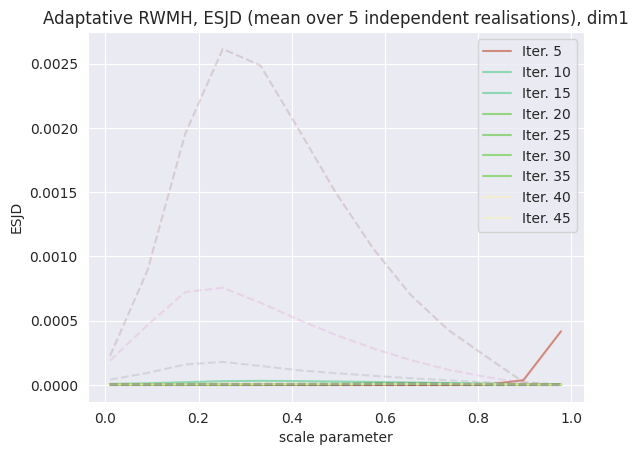

In [5]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
color_set
idx = 2
mpm1 = PKLs[idx]['res'][0].shape[2]*(PKLs[idx]['res'][0].shape[3]-1)
for j in range(1, PKLs[idx]['res'][5].shape[1]):
    if j % 5 ==0:
        plt.plot(GRID_ESJD, PKLs[idx]['res'][5].mean(axis=0)[j,:]/mpm1, label=f"Iter. {str(j)}", alpha=0.5, color=color_set[j//10], linestyle="solid")
    else:
        plt.plot(GRID_ESJD, PKLs[idx]['res'][5].mean(axis=0)[j,:]/mpm1, alpha=0.2, linestyle="--")
plt.legend()
plt.title(f"criteria function (mean over {PKLs[idx]['res'][5].shape[0]} independent realisations), dim{PKLs[idx]['res'][0].shape[-1]}")
plt.ylabel("criteria function")
plt.xlabel("theta")
plt.savefig(f"{PKL_titles[idx]}criteria_function.png")


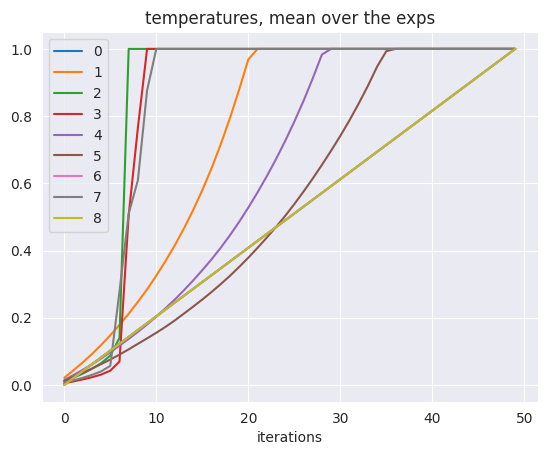

In [6]:
for idx in range(n):
    plt.plot(np.mean(PKLs[idx]['res'][6], axis=0), label=f'{idx}')
plt.title('temperatures, mean over the exps')
plt.xlabel('iterations')
plt.legend()

/tmp/ipykernel_3385/1264815359.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'iteration')

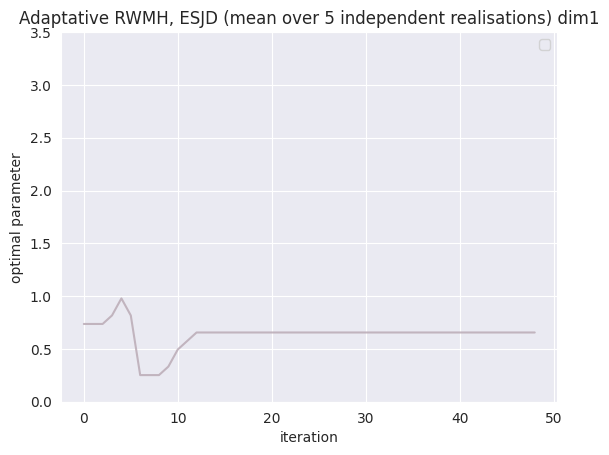

In [13]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
color_set
idx = 1
print(PKL_titles[idx])
mpm1 = PKLs[idx]['res'][0].shape[2]*(PKLs[idx]['res'][0].shape[3]-1)
max=13
plt.plot([GRID_ESJD[:max][np.argmax(PKLs[idx]['res'][5].mean(axis=0)[j,:max])] for j in range(1, PKLs[idx]['res'][5].shape[1])], alpha=0.9, color=color_set[j//10], linestyle="solid")
plt.ylim(0.0, 1.)
plt.legend()
plt.title(f"Adaptative RWMH, ESJD (mean over {PKLs[idx]['res'][5].shape[0]} independent realisations) dim{PKLs[idx]['res'][0].shape[-1]}")
plt.ylabel("optimal parameter w.r.t to mean estimate of E")
plt.xlabel("iteration")
plt.savefig(f"{PKL_titles[idx]}optimal_parameter_wrt_to_mean_estimate_of_E.png")

In [11]:
GRID_ESJD[:13]

Array([0.01      , 0.09070707, 0.17141414, 0.2521212 , 0.33282828,
       0.41353536, 0.49424243, 0.57494944, 0.6556566 , 0.73636365,
       0.81707066, 0.8977778 , 0.97848487], dtype=float32)

Text(0.5, 1.0, 'criteria function for different \\theta')

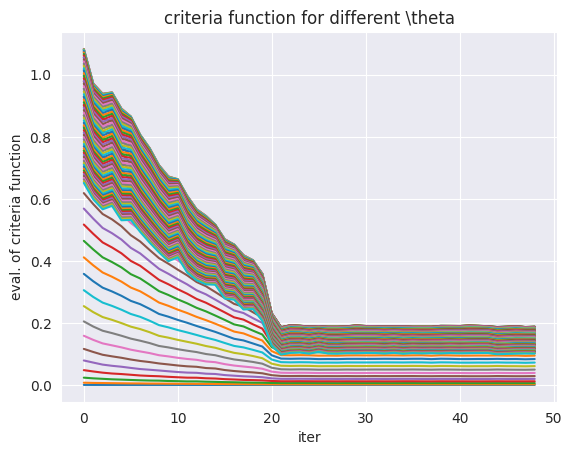

In [48]:
idx = 2
for t in range(PKLs[idx]['res'][5].shape[-1]):
    plt.plot(PKLs[idx]['res'][5][..., t][...,1:].mean(axis=0))
plt.xlabel("iter")
plt.ylabel("eval. of criteria function")
plt.title(r"criteria function for different \theta")

In [25]:
PKLs[idx]['res'][5].shape[-1]

100

Text(0.5, 1.0, 'ESS')

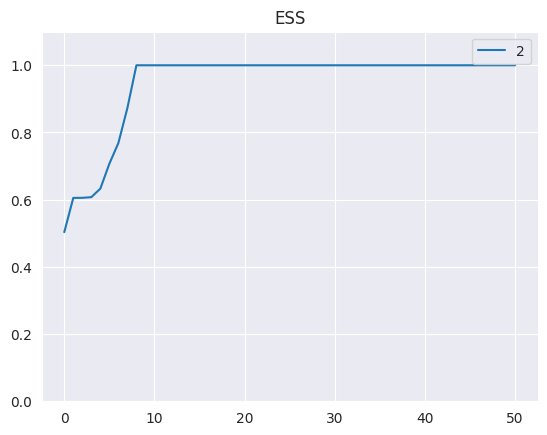

In [14]:
idx=2
weights = np.exp(PKLs[idx]['res'][1][:,:,].reshape((*PKLs[idx]['res'][1].shape[:2], -1)))
num_particles = weights.shape[-1]
plt.ylim((0, 1.1))
plt.plot(np.mean(1/np.sum(np.square(weights), axis=-1).T/num_particles, axis=-1), label=idx)
plt.legend()
plt.title("ESS")

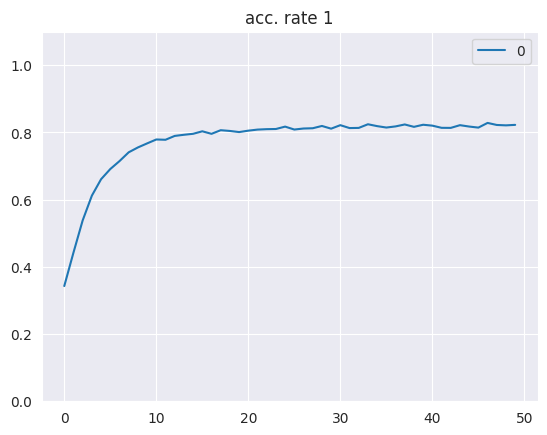

In [15]:
idx=0
plt.plot(PKLs[idx]['res'][3][0].mean(axis=[1, 2]), label=idx)
plt.ylim((0, 1.1))
plt.title(f"acc. rate {PKLs[idx]['res'][0].shape[-1]}")
plt.legend()
plt.savefig(f"{PKL_titles[idx]}acc_rate.png")

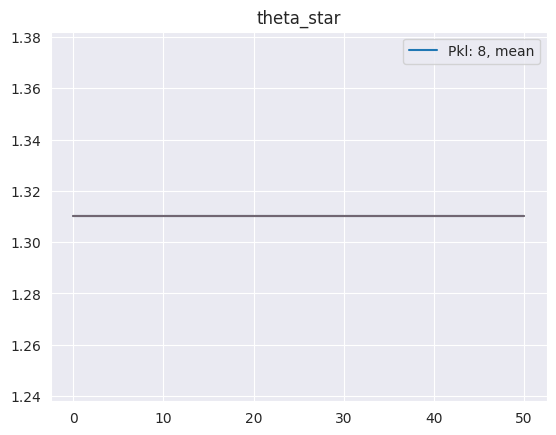

In [56]:
idx=1
plt.plot(PKLs[idx]['res'][2][...,0].mean(axis=0), label=f"Pkl: {idx}, mean")
plt.plot(PKLs[idx]['res'][2][...,0].T, alpha=0.2)
plt.plot(np.mean(PKLs[idx]['res'][6], axis=0), label=f"mean temp", color="black", linestyle="--")
plt.title(f"theta_star dim{PKLs[idx]['res'][0].shape[-1]} ")
plt.savefig(f"{PKL_titles[idx]}theta_star.png")
plt.legend()

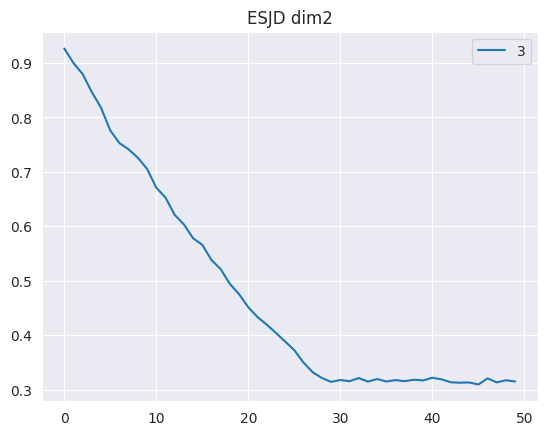

In [75]:
idx=3
plt.plot(np.sum(np.square(np.diff(PKLs[idx]['res'][0], axis=-2, n=1)), axis=-1).mean((0, 2, 3))[1:], label=idx)
plt.title(f"ESJD dim{PKLs[idx]['res'][0].shape[-1]}")
plt.legend()

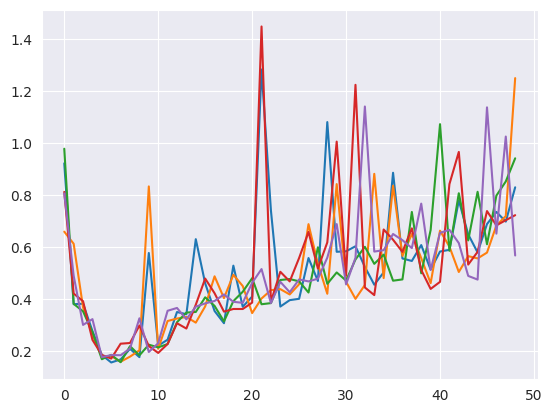

In [95]:
import jax
import jax.numpy as jnp
idx=0
is_weights = jnp.exp(PKLs[idx]['res'][4])
is_weights = is_weights.reshape(is_weights.shape[:2] + (-1,))
is_weights_shape = is_weights.shape
var_over_mean_sq = jnp.vectorize(lambda s: jnp.var(s)/jnp.mean(s)**2, signature="(n)->()")(is_weights)
plt.plot(var_over_mean_sq.T[1:])